### Name: Sean Dang
### PSID: 2518173

# Task 1: Imputing and Encoding

In [60]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Decision tree
from sklearn.tree import DecisionTreeClassifier


# Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [61]:
# Read in data
df = pd.read_csv('train.csv')

In [62]:
# Let's choose some features
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
y = df["Survived"]
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    str    
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  889 non-null    str    
dtypes: float64(2), int64(3), str(2)
memory usage: 48.9 KB


In [63]:
# Find if here are any missing values
X.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [64]:
# Age has a lot of NaN, which stands for Not a Number, and we see in the csv that these are just empty and not available. Embarked has a couple
# We can choose to ignore those rows

X_remove_nan = X.dropna()
X_remove_nan.info()
X_remove_nan.isnull().sum()

<class 'pandas.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    712 non-null    int64  
 1   Sex       712 non-null    str    
 2   Age       712 non-null    float64
 3   SibSp     712 non-null    int64  
 4   Parch     712 non-null    int64  
 5   Fare      712 non-null    float64
 6   Embarked  712 non-null    str    
dtypes: float64(2), int64(3), str(2)
memory usage: 44.5 KB


Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [65]:
# we can also choose to impute the values
X_imputed = X.copy()
X_imputed["Age"] = X_imputed["Age"].fillna(X["Age"].mean())

X_imputed["Embarked"] = X_imputed["Embarked"].fillna("Not Known")
X_imputed.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

1. Use the features ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"] for training with "Survival" as the label that you are trying to predict. There are some missing values in these features (see code stub), your first task is to choose how to handle them. I have shown two methods. Explain the pros and cons of choosing each method [ 10 points]

- METHOD 1: Dropping NaNs

    + Pros: It provides a completely clean dataset with actual, unaltered data points. It prevents introducing artificial biases or variance that can occur when guessing (imputing) values.

    + Cons: We lose a significant amount of data. `Age` is missing ~177 values (roughly 10% of the dataset). Dropping these reduces the statistical power of our model. Furthermore, if the missing data is not perfectly random (e.g., perhaps older, wealthier people were less likely to have their age recorded), dropping them introduces survival bias into our training data.

- METHOD 2: Imputing Values

    + Pros: It preserves the size of our dataset, allowing the model to learn from the other valid features (like Pclass, Sex, Fare) in those 177 rows rather than throwing them away.

    + Cons: Imputing the mean for `Age` artificially reduces the variance of the age distribution and assumes the missing ages follow the exact same average as the known ages, which might not be true. Imputing "Not Known" for `Embarked` creates a brand-new categorical feature that might not have any real predictive power.

In [66]:
# "Sex" and "Embarked" are categorical values, we need to use One Hot Encoding to make them numerical values
X_imputed_encoded = pd.get_dummies(X_imputed, columns=['Sex', 'Embarked'], drop_first=True)
X_remove_nan_encoded = pd.get_dummies(X_remove_nan, columns=['Sex', 'Embarked'], drop_first=True)
display(X_imputed_encoded.head())

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Not Known,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,False,True
1,1,38.0,1,0,71.2833,False,False,False,False
2,3,26.0,0,0,7.9250,False,False,False,True
3,1,35.0,1,0,53.1000,False,False,False,True
4,3,35.0,0,0,8.0500,True,False,False,True


2. Use One Hot Encoding to change categorical variables to numerical values. I have done this for imputed data. Complete the exercise for imputed data and repeat for data with missing values removed. What are the other options available for encoding? Explain why OHE is good or not good for this exercise [ 10 points]

+ Other options available for enconding: Label encoding, Target encoding, and Frequency Encoding

+ OHE is good for this particular problem because our categorical variables (`Sex` and `Embarked`) are nominal — meaning they have no mathematical order. If we used Label Encoding, the algorithm might incorrectly assume that Queenstown (1) is "less than" Southampton (2). OHE prevents this false ordinality. It is also highly effective here because the number of unique categories is very low. If we had hundreds of categories, OHE would cause the dimensionality, but with only 2 sexes and 3-4 embarkation points, it is the perfect choice.


In [67]:
# Repeat for X_removed

In [68]:
dt = DecisionTreeClassifier()

In [69]:
# Divide data into training and test datasets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_imputed_encoded, y, test_size=0.2, random_state=42)

In [70]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [71]:
# Make predictions
y_pred = rf.predict(X_test)

In [72]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")

Random Forest Accuracy: 0.8101


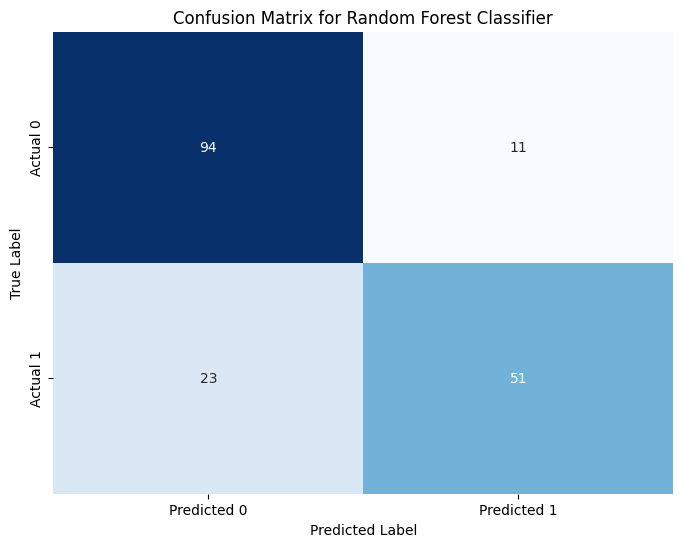

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()

3. Divide data into training and test datasets. Use Random Forest algorithm to obtain a classifier (you can use sklearn methods). What are the hyper parameters you can use for Random Forest? Which ones did you choose to use, why? Plot the confusion matrix for your results on the test dataset. Explain your results [15 points]

+ Available Hyperparameters for Random Forest: n_estimators, max_depth, min_samples_split, min_sample_leaf, bootstrap

+ I chose:
    - `n_estimators = 100`: A standard baseline. Enough trees to stabilize the model's predictions through majority voting without being computationally heavy.
    - `max_depth = 5`: I introduced a depth limit to prevent **overfitting**. If left at default (None), the trees will expand until all leaves are pure, which makes the model memorize the training data but fail on unseen test data.
    - `random_state=42`: Ensures reproducibility so the results are identical on every run.

+ Interpreting the Confusion Matrix:
    - True Negatives (Top Left): Passengers the model correctly predicted would not survive. 
    - True Positives (Bottom Right): Passengers the model correctly predicted would survive.
    - False Positives (Top Right): Passengers the model predicted survived, but they actually did not (Type I error).
    - False Negatives (Bottom Left): Passengers the model predicted died, but they actually survived (Type II error).

+ The model generally performs well, capturing the majority of actual deaths and survivals accurately. False negatives and false positives indicate areas where the simple features (like `Age` or `Pclass`) weren't enough to capture the nuance of a specific passenger's fate, possibly because of the simplistic mean imputation we used for Age.